# Smart Energy Analytics

## Notebook 06: Advanced LSTM Model

### Objective

The goal of this notebook is to improve the baseline LSTM model by using a deeper neural network architecture and advanced training techniques.

In this notebook we will:

- Load the daily energy dataset
- Normalize the data
- Create time sequences
- Build an Advanced LSTM model
- Train the model using EarlyStopping
- Evaluate performance
- Compare predictions
- Save the best model for deployment

# Section 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint

# Section 2: Load Dataset

In [3]:
data = pd.read_csv("daily_energy_data.csv")

data.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
1,2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2,2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
3,2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
4,2006-12-20,1.545658,0.111804,242.308063,6.467361,0.000000,1.838889,9.765972


# Section 3: Data Preparation

In [4]:
data = data.drop(columns=["Datetime"])

data = data.dropna().reset_index(drop=True)

# Section 4: Normalize Data

In [5]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

# Section 5: Create Sequences

In [6]:
WINDOW = 30

X = []
y = []

for i in range(WINDOW, len(scaled_data)):

    X.append(
        scaled_data[i-WINDOW:i]
    )

    y.append(
        scaled_data[i,0]
    )

X = np.array(X)

y = np.array(y)

print(X.shape)
print(y.shape)

(1403, 30, 7)
(1403,)


# Section 6: Build Advanced LSTM Model

In this section, we build an improved LSTM architecture.

Improvements include:

- Two stacked LSTM layers
- More hidden units
- Dropout regularization
- Adam optimizer
- Mean Squared Error loss

This model is expected to capture more complex temporal patterns than the baseline model.

In [7]:
def build_model(input_shape):

    model = Sequential()

    # First LSTM Layer
    model.add(
        LSTM(
            128,
            return_sequences=True,
            input_shape=input_shape
        )
    )

    model.add(
        Dropout(0.3)
    )

    # Second LSTM Layer
    model.add(
        LSTM(
            64
        )
    )

    model.add(
        Dropout(0.3)
    )

    # Fully Connected Layer
    model.add(
        Dense(
            32,
            activation="relu"
        )
    )

    # Output Layer
    model.add(
        Dense(1)
    )

    model.compile(

        optimizer="adam",

        loss="mse",

        metrics=["mae"]

    )

    return model

In [8]:
model = build_model(
    (X.shape[1], X.shape[2])
)

model.summary()

c:\Users\abdul\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

# Section 7: Train the Advanced LSTM Model

In this section, we train the Advanced LSTM model using several callbacks to improve the training process.

The training strategy includes:

- EarlyStopping to prevent overfitting.
- ReduceLROnPlateau to automatically reduce the learning rate when validation loss stops improving.
- ModelCheckpoint to save the best-performing model.

In [9]:
# ----------------------------------------
# Train-Test Split
# ----------------------------------------

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [10]:
# ----------------------------------------
# Build Model
# ----------------------------------------

model = build_model(
    (X_train.shape[1], X_train.shape[2])
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,153 (473.25 KB)

 Trainable params: 121,153 (473.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ----------------------------------------
# Callbacks
# ----------------------------------------

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "advanced_lstm.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1

)

In [12]:
# ----------------------------------------
# Train Model
# ----------------------------------------

history = model.fit(

    X_train,

    y_train,

    validation_data=(X_test, y_test),

    epochs=50,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1

)

Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0305 - mae: 0.1362
Epoch 1: val_loss improved from None to 0.00629, saving model to advanced_lstm.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0199 - mae: 0.1082 - val_loss: 0.0063 - val_mae: 0.0604 - learning_rate: 0.0010
Epoch 2/50
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0119 - mae: 0.0821
Epoch 2: val_loss did not improve from 0.00629
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0123 - mae: 0.0834 - val_loss: 0.0064 - val_mae: 0.0605 - learning_rate: 0.0010
Epoch 3/50
35/36 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0116 - mae: 0.0801
Epoch 3: val_loss improved from 0.00629 to 0.00619, saving model to advanced_lstm.keras
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0121 - mae: 0.0816 - val_loss: 0.0062 - val_mae: 0.0592 - learning_rate: 0.0010
Epoch 4/50
34/36 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0117 - mae: 0.0816
Epoch 4: val_loss did not improve from 0.00619
36/36 ━━━━━━━━━━━━━━━━━

In [13]:
# ----------------------------------------
# Load Best Model
# ----------------------------------------

from tensorflow.keras.models import load_model

best_model = load_model("advanced_lstm.keras")

# Section 8: Model Evaluation

In this section, we evaluate the performance of the Advanced LSTM model using standard regression metrics.

The evaluation includes:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

We also visualize:

- Training vs Validation Loss
- Training vs Validation MAE
- Actual vs Predicted Values

In [14]:
# ============================================
# Predict Test Data
# ============================================

predictions = best_model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [15]:
# ============================================
# Evaluation Metrics
# ============================================

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.0553
RMSE : 0.0749
R²   : 0.4248


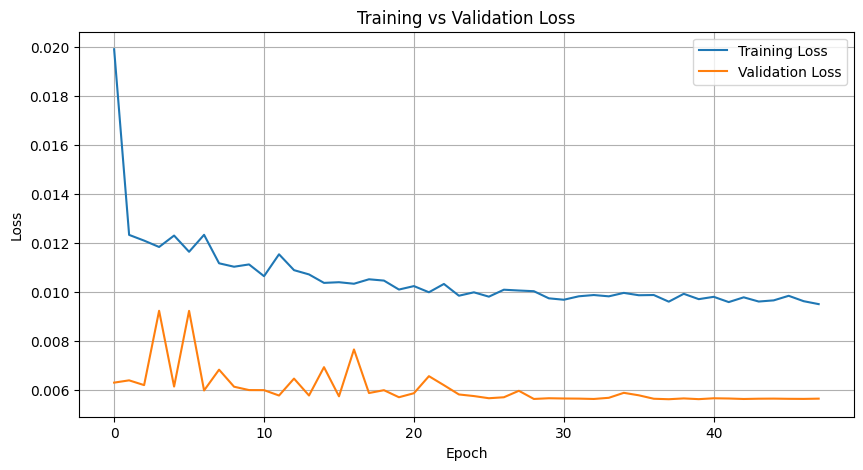

In [16]:
# ============================================
# Loss Curves
# ============================================

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

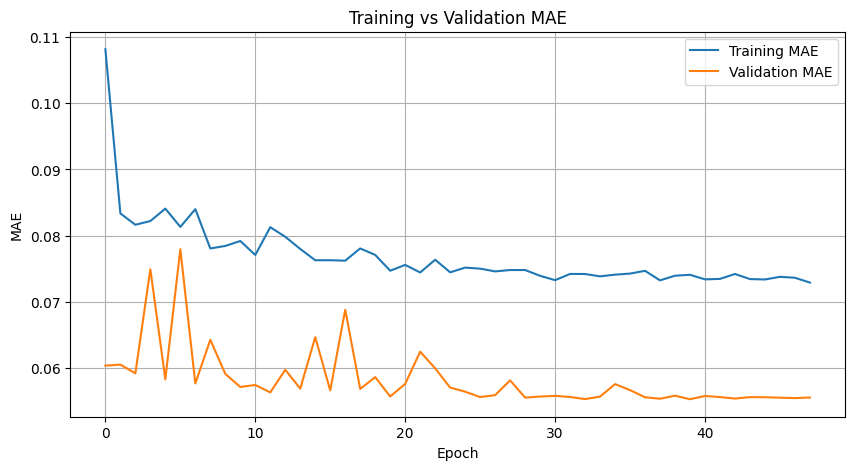

In [17]:
# ============================================
# MAE Curves
# ============================================

plt.figure(figsize=(10,5))

plt.plot(history.history["mae"], label="Training MAE")

plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("Training vs Validation MAE")

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.legend()

plt.grid(True)

plt.show()

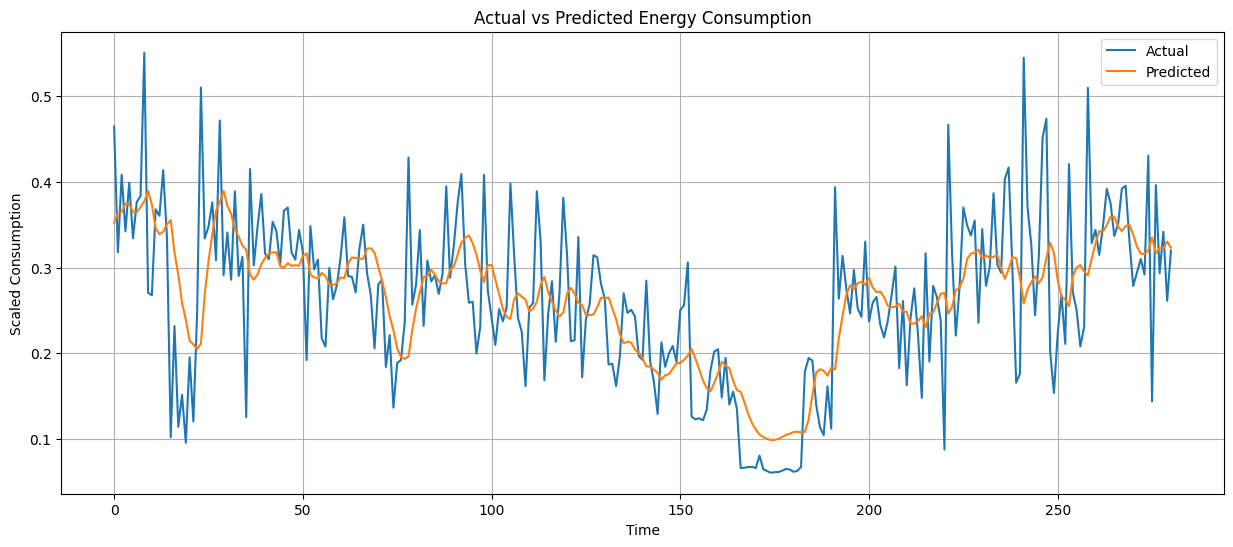

In [18]:
# ============================================
# Actual vs Predicted
# ============================================

plt.figure(figsize=(15,6))

plt.plot(
    y_test,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title("Actual vs Predicted Energy Consumption")

plt.xlabel("Time")

plt.ylabel("Scaled Consumption")

plt.legend()

plt.grid(True)

plt.show()

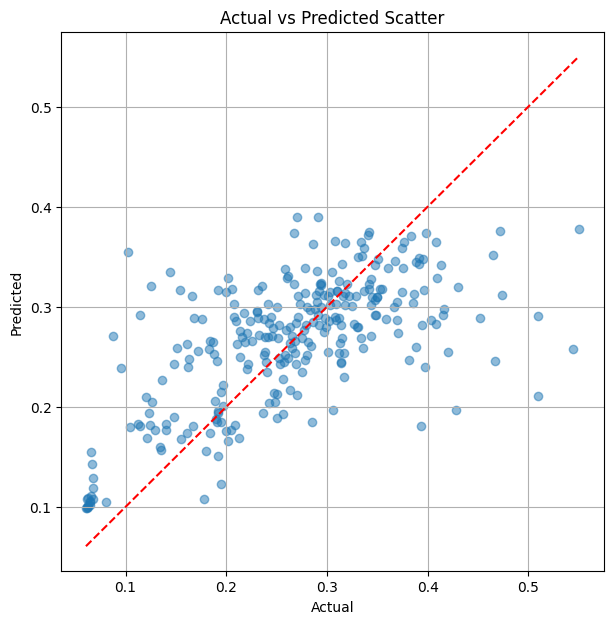

In [19]:
# ============================================
# Scatter Plot
# ============================================

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.title("Actual vs Predicted Scatter")

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.grid(True)

plt.show()

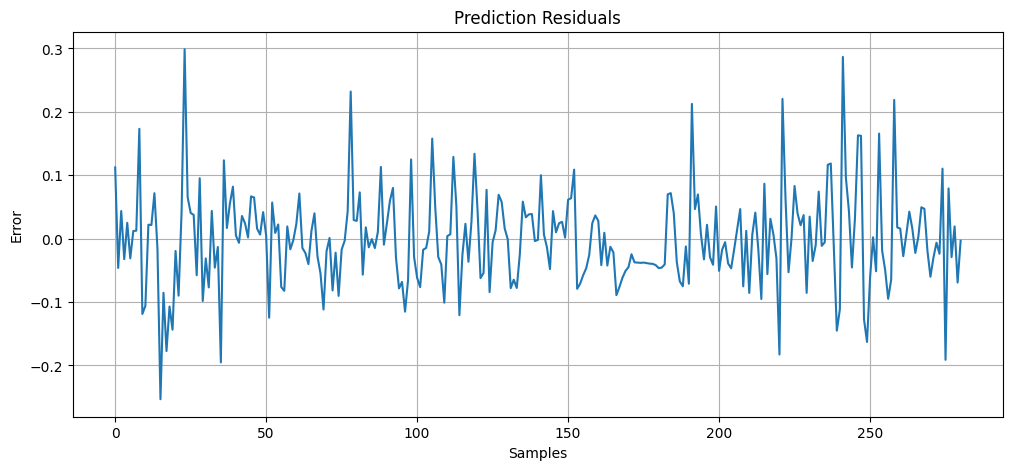

In [20]:
# ============================================
# Residual Analysis
# ============================================

residuals = y_test - predictions.flatten()

plt.figure(figsize=(12,5))

plt.plot(residuals)

plt.title("Prediction Residuals")

plt.xlabel("Samples")

plt.ylabel("Error")

plt.grid(True)

plt.show()